In [138]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

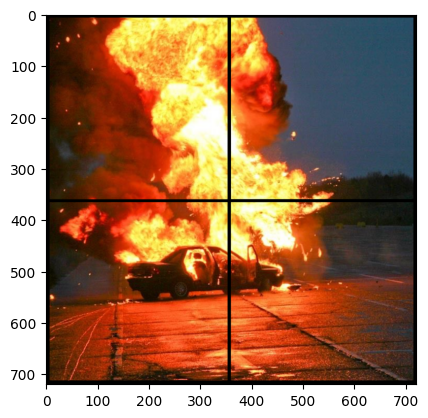

(720, 720, 3)


In [139]:
meledak = plt.imread('Assets/Meledak.png')
bunga = plt.imread('Assets/Bunga.png')
langit = plt.imread('Assets/Langit.png')
windut = plt.imread('Assets/Windut.png')

plt.imshow(meledak, cmap ='gray')
plt.show()
print(meledak.shape)


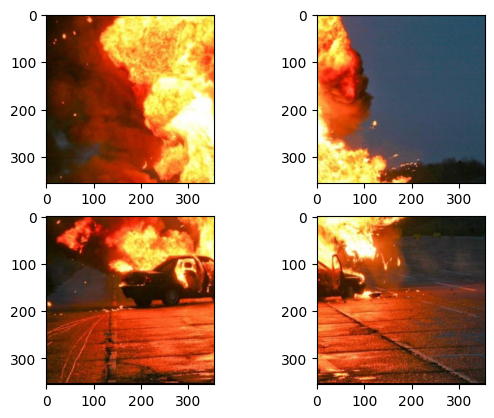

In [140]:
mel1 = meledak[5:355, 5:350]
mel2 = meledak[5:360, 360:715]
mel3 = meledak[370:715, 5:350]
mel4 = meledak[370:715, 360:715]

mel1 = cv.resize(mel1, (355, 355))
mel2 = cv.resize(mel2, (355, 355))
mel3 = cv.resize(mel3, (355, 355))
mel4 = cv.resize(mel4, (355, 355))

plt.subplot(2, 2, 1)
plt.imshow(mel1)

plt.subplot(2, 2, 2)
plt.imshow(mel2)

plt.subplot(2, 2, 3)
plt.imshow(mel3)

plt.subplot(2, 2, 4)
plt.imshow(mel4)


In [141]:
def ukuran_min(gambar):
    baris_min = min(len(citra) for citra in gambar)
    kolom_min = min(len(citra[0]) for citra in gambar)
    return baris_min, kolom_min

def potong(citra, tinggi, lebar):
    return [row[:lebar] for row in citra[:tinggi]]

def resize_semua(gambar):
    tinggi_min, lebar_min = ukuran_min(gambar)
    return [potong(citra, tinggi_min, lebar_min) for citra in gambar]

def ukuran_max(gambar):
    baris_max = max(len(citra) for citra in gambar)
    kolom_max = max(len(row) for citra in gambar for row in citra)
    return baris_max, kolom_max

def normalisasi(citra, baris_tujuan, kolom_tujuan):
    hasil = []
    for i in range(baris_tujuan):
        baris = []
        for j in range(kolom_tujuan):
            if i < len(citra) and j < len(citra[i]):
                baris.append(citra[i][j])
            else:
                baris.append(0)
        hasil.append(baris)
    return hasil

def gabung_2x2(citra1, citra2, citra3, citra4):
    citra1, citra2, citra3, citra4 = resize_semua([citra1, citra2, citra3, citra4])

    b, k = ukuran_max([citra1, citra2, citra3, citra4])
    i1 = normalisasi(citra1, b, k)
    i2 = normalisasi(citra2, b, k)
    i3 = normalisasi(citra3, b, k)
    i4 = normalisasi(citra4, b, k)

    gabung = []
    for i in range(b * 2):
        baris = []
        for j in range(k * 2):
            if i < b and j < k:
                baris.append(i1[i][j]) 
            elif i < b and j >= k:
                baris.append(i2[i][j - k]) 
            elif i >= b and j < k:
                baris.append(i3[i - b][j])
            else:
                baris.append(i4[i - b][j - k]) 
        gabung.append(baris)

    return gabung

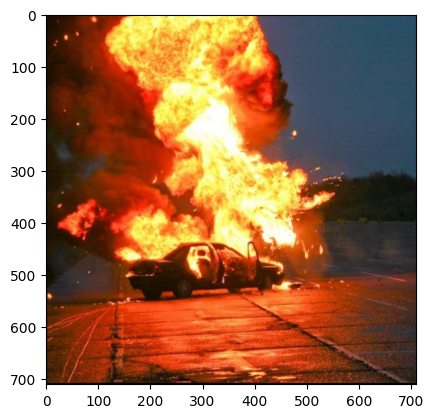

In [142]:
gabung = gabung_2x2(mel1, mel2, mel3, mel4)
plt.imshow(gabung)


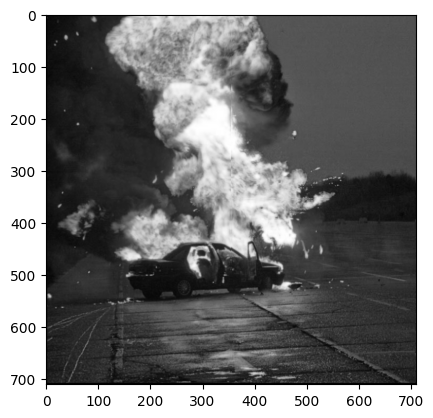

In [143]:
gabung = np.array(gabung, dtype=np.float32)  # ← tambahkan ini

mel_grey = cv.cvtColor(gabung, cv.COLOR_BGR2GRAY)
plt.imshow(mel_grey, cmap='gray')
plt.show()

In [144]:
# Fungsi untuk ekualisasi histogram
def ekualisasi_histogram(citra):
    panjang, lebar = citra.shape

    # Hitung histogram
    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    # Hitung CDF
    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(histogram[:i+1])

    # Normalisasi CDF
    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    cdf_norm = np.round((cdf - cdf_min) / (panjang * lebar - cdf_min) * 255).astype(int)

    # Petakan nilai baru
    hasil = np.zeros_like(citra, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil

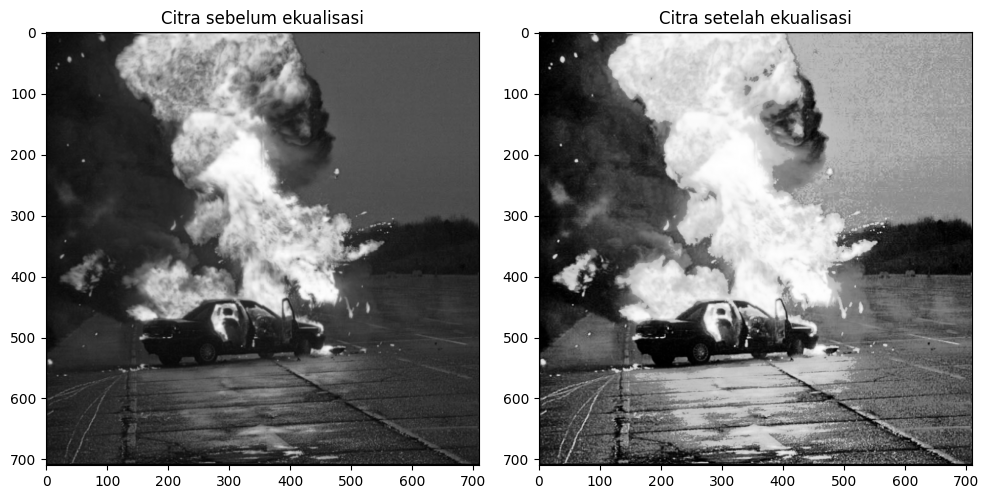

In [146]:
citra_gabung = (mel_grey * 255).astype(np.uint8)

panjang, lebar = citra_gabung.shape
hasil = ekualisasi_histogram(citra_gabung)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(citra_gabung, cmap='gray')
plt.title("Citra sebelum ekualisasi")
plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap='gray')
plt.title("Citra setelah ekualisasi")
plt.tight_layout()
plt.show()

In [149]:
def hitung_histogram(citra):
    import numpy as np
    
    if len(citra.shape) == 3:
        citra = np.mean(citra, axis=2)

    if citra.max() <= 1.0:
        citra = (citra * 255)

    citra = citra.astype('uint8')

    hist = np.bincount(citra.flatten(), minlength=256)
    return hist

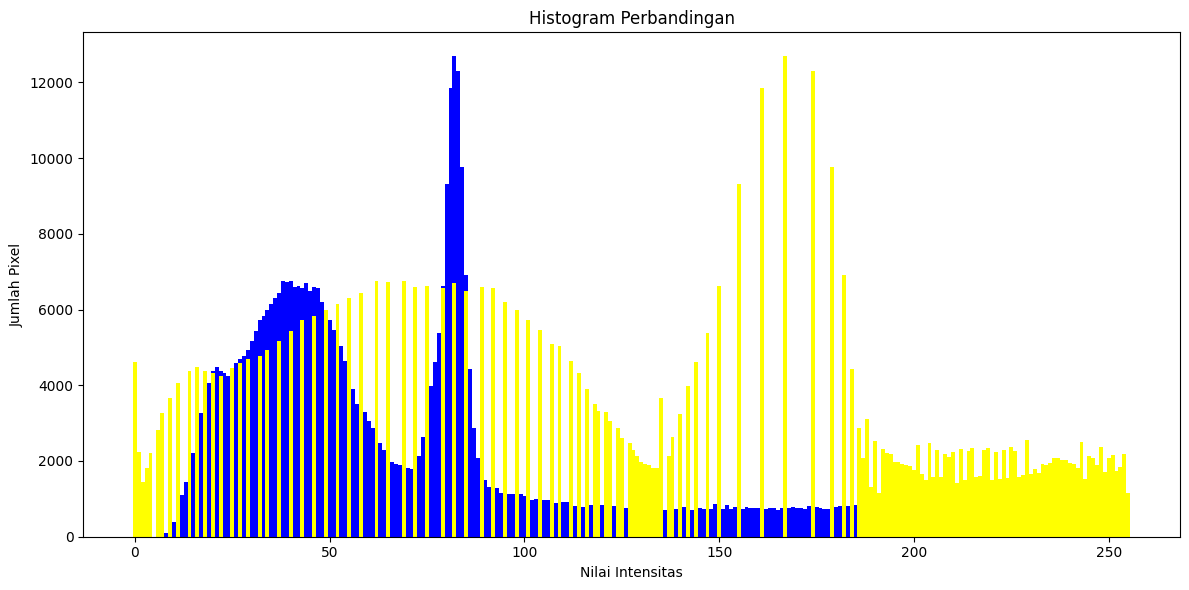

In [ ]:
histo = hitung_histogram(citra_gabung) # sebelum di tambahkan atribut
histoEku = hitung_histogram(hasil) # setelah di tambahkan atribut

plt.figure(figsize=(12, 6))

plt.bar(range(256), histo, width=1, color='blue') # sebelum di tambahkan atribut

plt.bar(range(256), histoEku, width=1, color='yellow') # setelah di tambahkan atribut

plt.title('Histogram Perbandingan')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

In [147]:
def spesifikasi_histogram(citra_asal, citra_target): 
    hist_asal = np.zeros(256, dtype=int) 
    hist_target = np.zeros(256, dtype=int) 
 
    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 
 
    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 
 
    map_hist = np.zeros(256, dtype=np.uint8) 
 
    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
 
    return hasil

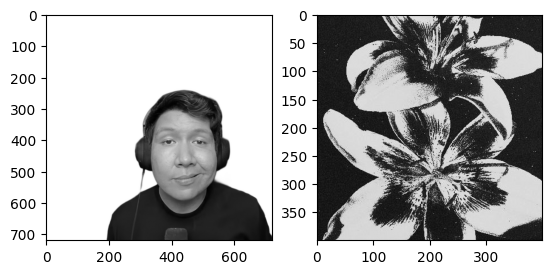

In [156]:
windut_grey = cv.cvtColor(windut, cv.COLOR_BGR2GRAY)
bunga_grey = cv.cvtColor(bunga, cv.COLOR_BGR2GRAY)

plt.subplot(1, 2, 1)
plt.imshow(windut_grey, cmap ='gray')
plt.subplot(1, 2, 2)
plt.imshow(bunga_grey, cmap ='gray')

In [162]:
def fungsi_dua_a(citra_1, citra_2): 
    return citra_1 + citra_2 

<function matplotlib.pyplot.show(close=None, block=None)>

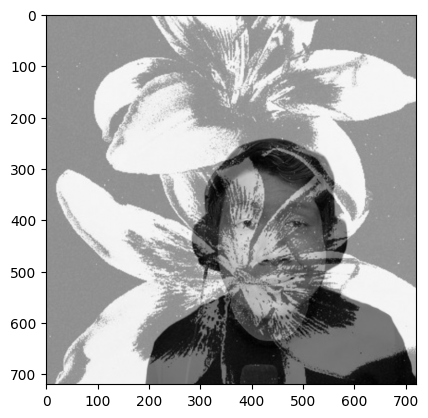

In [164]:
bunga_grey = cv.resize(bunga_grey, (720, 720))
winbu = fungsi_dua_a (windut_grey, bunga_grey)

plt.imshow(winbu, cmap='gray')
plt.show

C:\Users\LENOVO LOQ\AppData\Local\Temp\ipykernel_14740\1226404711.py:11: RuntimeWarning: invalid value encountered in divide
  cdf_asal = cdf_asal / cdf_asal[-1]
C:\Users\LENOVO LOQ\AppData\Local\Temp\ipykernel_14740\1226404711.py:12: RuntimeWarning: invalid value encountered in divide
  cdf_target = cdf_target / cdf_target[-1]


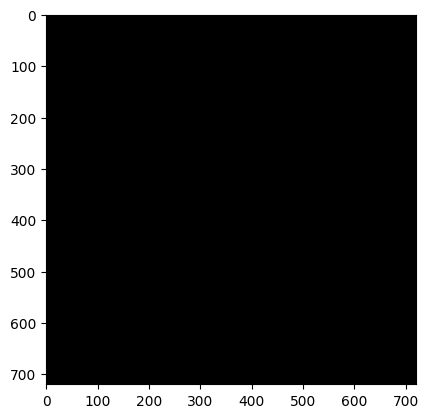

In [165]:
windut_sp = spesifikasi_histogram (windut_grey, bunga_grey)

plt.imshow(windut_sp, cmap = 'gray')